# Resume-Scan — Chatbot Evaluation Pipeline

End-to-end evaluation of the resume/job RAG chatbot, in two layers:

**Layer 1 — Retrieval.** Synthetic ground-truth queries (each one generated from a single known
resume or job posting) are searched against the live Qdrant collections, and the ranked result
lists are scored with rank-aware metrics: **NDCG@k** with its **DCG/IDCG** components, **MRR**,
**accuracy@k** (hit rate in the top *k*) and precision@k.

**Layer 2 — Generation / hallucination.** Question–answer pairs grounded in single documents are
answered by the production pipeline (the *exact* production system prompt and the same context
shaping as `services/ai-agents/core/tools.py`), then scored with **RAGAS**:

- *faithfulness* checks every claim in the answer against the retrieved contexts — a low score
  means unsupported claims, i.e. **hallucination**;
- *answer_correctness* compares the predicted answer against the ground-truth answer;
- answer relevancy and context precision/recall complete the picture.

> **Kernel:** run this notebook with the `.venv-eval` environment
> (`pre-processing/.venv-eval`, installed from `pre-processing/requirements-eval.txt`).
> All reusable logic lives in the `evaluation/` package — this notebook only orchestrates
> and reports. See `evaluation/README.md` for setup, metric definitions and cost notes.

## 0 · Setup & health checks

Imports, configuration, and a quick sanity pass: both Qdrant collections must exist, and the API
keys must be present in `pre-processing/.env`. Only booleans and counts are printed — never key
values.

In [1]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd

from evaluation import config
from evaluation.dataset import build_qa_dataset, build_retrieval_dataset
from evaluation.generation_eval import hallucination_report, run_generation, run_ragas
from evaluation.retrieval_eval import (
    run_graded_ndcg,
    run_retrieval_eval,
    summarize_retrieval,
)

pd.set_option("display.max_colwidth", 80)

# Health checks — booleans and counts only, NEVER secret values.
print("OPENAI_API_KEY present:", bool(config.OPENAI_API_KEY))
print("QDRANT_API_KEY present:", bool(config.QDRANT_API_KEY))

qdrant = config.get_qdrant()
existing = {c.name for c in qdrant.get_collections().collections}
for collection in (config.CV_COLLECTION, config.JD_COLLECTION):
    ok = collection in existing
    points = qdrant.count(collection).count if ok else None
    print(f"collection {collection!r}: exists={ok}, points={points}")

print("system prompt found:", config.SYSTEM_PROMPT_PATH.exists())
print("records.json found:", config.RECORDS_PATH.exists())
print("jobs.json found:", config.JOBS_PATH.exists())

OPENAI_API_KEY present: True
QDRANT_API_KEY present: True
collection 'cv_information_technology': exists=True, points=521
collection 'jd_jobs': exists=True, points=5830
system prompt found: True
records.json found: True
jobs.json found: True


/Users/anh/Doc/resume-scan-project/pre-processing/evaluation/config.py:67: UserWarning: Api key is used with an insecure connection.
  return qdrant_client.QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)


## Parameters

Every knob for this run lives in the next cell. `RETRIEVAL_N` / `QA_N` / `SEED` are part of the
dataset cache filenames under `eval_data/`, so re-running with the same values reuses cached
LLM-generated datasets (and cached generations) instead of re-spending API calls. Set
`FORCE_REBUILD = True` to regenerate everything from scratch.

In [2]:
# ------------------------------------------------------------------ PARAMETERS
RETRIEVAL_N = 40                # retrieval queries per kind (cv / jd) — layer 1
QA_N = 15                       # QA pairs per kind — layer 2
SEED = 42                       # sampling seed; part of every cache filename
K_VALUES = (1, 3, 5, 10)        # cutoffs for accuracy / precision / DCG / NDCG
SEARCH_K = 10                   # depth of the ranked list fetched from Qdrant
CONTEXT_K = 5                   # retrieved groups fed to the answer model (layer 2)
HALLUCINATION_THRESHOLD = 0.7   # faithfulness below this => flagged as hallucination
GRADED_N = 8                    # queries for the optional LLM-graded NDCG pass
FORCE_REBUILD = False           # True => ignore eval_data caches (re-spends LLM calls)

## 1 · Layer 1 — Retrieval evaluation

There is no human-labelled gold set for this corpus, so we synthesise one: for each sampled
document the judge model (`gpt-4.1-mini`) writes a recruiter-style (cv) or job-seeker-style (jd)
search query grounded **only** in that document. The document's `id` becomes the query's single
relevant id (binary relevance, gain 1.0). Queries are embedded with the same
`text-embedding-3-small` model that indexed the collections, and searched with the same grouped
Qdrant query (`query_points_groups`, one group per resume/job id) the production agent uses.

In [3]:
retrieval_cv = build_retrieval_dataset("cv", n=RETRIEVAL_N, seed=SEED, force=FORCE_REBUILD)
retrieval_jd = build_retrieval_dataset("jd", n=RETRIEVAL_N, seed=SEED, force=FORCE_REBUILD)
print(f"cv: {len(retrieval_cv)} queries | jd: {len(retrieval_jd)} queries")

for kind, ds in (("cv", retrieval_cv), ("jd", retrieval_jd)):
    print(f"\n--- sample {kind} queries ---")
    for item in ds[:3]:
        print(f"  [relevant_id={item['relevant_id']}] {item['query']}")

cv: 40 queries | jd: 40 queries

--- sample cv queries ---
  [relevant_id=29051656] Oracle DBA with over 6 years experience managing Oracle 10g to 12c, SQL Server 2008 and 2012, skilled in Oracle Enterprise Linux, AWS RDS and EC2, RMAN, DataPump, GoldenGate, and database migration services
  [relevant_id=13385306] Director of Information Technology with expertise in C#, Oracle SQL, SQL Server, SharePoint, ASP.NET, and Agile methodologies, experienced in leading application development and IT strategy in banking and healthcare sectors
  [relevant_id=10553553] IT Manager with expertise in Active Directory, Microsoft Exchange 2003, Windows Server, SQL, and Milestone Advanced Certified Partner for video surveillance, experienced in enterprise platform management, disaster recovery, and project tracking using Waterfall and Scrum methodologies

--- sample jd queries ---
  [relevant_id=linkedin_4424569183] Senior Data Scientist role in InsurTech with 8+ years experience, expertise in Python, 

In [4]:
# CV retrieval: one row per query (rank of the true resume + all metrics).
df_cv = run_retrieval_eval(retrieval_cv, k_values=K_VALUES, search_k=SEARCH_K)
df_cv.head()

,query,relevant_id,retrieved,rank,mrr,accuracy@1,precision@1,dcg@1,idcg@1,ndcg@1,...,accuracy@5,precision@5,dcg@5,idcg@5,ndcg@5,accuracy@10,precision@10,dcg@10,idcg@10,ndcg@10
0,"Oracle DBA with over 6 years experience managing Oracle 10g to 12c, SQL Serv...",29051656,"[29051656, 18187364, 20001721, 13385306, 28126340, 18301617, 31243710, 17111...",1.0,1.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,0.2,1.00000,1.0,1.00000,1.0,0.1,1.000000,1.0,1.000000
1,"Director of Information Technology with expertise in C#, Oracle SQL, SQL Ser...",13385306,"[32959732, 13385306, 26801767, 92069209, 13405733, 23864648, 37242217, 41344...",2.0,0.500000,0.0,0.0,0.0,1.0,0.0,...,1.0,0.2,0.63093,1.0,0.63093,1.0,0.1,0.630930,1.0,0.630930
2,"IT Manager with expertise in Active Directory, Microsoft Exchange 2003, Wind...",10553553,"[10247517, 11584809, 10089434, 31243710, 17688766, 10553553, 13405733, 51363...",6.0,0.166667,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.00000,1.0,0.00000,1.0,0.1,0.356207,1.0,0.356207
3,Microsoft Certified Systems Engineer with experience as Information Technolo...,37764298,"[39413067, 10247517, 91635250, 31243710, 10089434, 52246737, 66832845, 38753...",NaN,0.000000,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.00000,1.0,0.00000,0.0,0.0,0.000000,1.0,0.000000
4,Senior Oracle Database Administrator and Information Security Officer with C...,18187364,"[18187364, 29051656, 20879311, 20001721, 37242217, 13385306, 10840430, 20237...",1.0,1.000000,1.0,1.0,1.0,1.0,1.0,...,1.0,0.2,1.00000,1.0,1.00000,1.0,0.1,1.000000,1.0,1.000000


In [5]:
# JD retrieval: same, over the job-description collection.
df_jd = run_retrieval_eval(retrieval_jd, k_values=K_VALUES, search_k=SEARCH_K)
df_jd.head()

,query,relevant_id,retrieved,rank,mrr,accuracy@1,precision@1,dcg@1,idcg@1,ndcg@1,...,accuracy@5,precision@5,dcg@5,idcg@5,ndcg@5,accuracy@10,precision@10,dcg@10,idcg@10,ndcg@10
0,"Senior Data Scientist role in InsurTech with 8+ years experience, expertise ...",linkedin_4424569183,"[indeed_in-a351bdf9575a6478, linkedin_4403900542, indeed_in-3c684fb3f367d045...",5.0,0.2,0.0,0.0,0.0,1.0,0.0,...,1.0,0.2,0.386853,1.0,0.386853,1.0,0.1,0.386853,1.0,0.386853
1,Information Technology Consultant contract role with 5+ years in Java Seleni...,indeed_in-35f4bd08b3a4f400,"[indeed_in-35f4bd08b3a4f400, indeed_in-bb659ffbb262a5f4, indeed_in-e51e7d954...",1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.2,1.000000,1.0,1.000000,1.0,0.1,1.000000,1.0,1.000000
2,"Azure Data Engineer contract role in banking with 8+ years experience, exper...",indeed_in-0de2ea6067aca11e,"[indeed_in-0de2ea6067aca11e, indeed_in-4de904ad2eeb4395, indeed_in-ad8eb32bb...",1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.2,1.000000,1.0,1.000000,1.0,0.1,1.000000,1.0,1.000000
3,Quantitative Researcher position requiring expertise in statistical analysis...,linkedin_4439798194,"[linkedin_4359164705, linkedin_4457805452, linkedin_4425458806, linkedin_445...",5.0,0.2,0.0,0.0,0.0,1.0,0.0,...,1.0,0.2,0.386853,1.0,0.386853,1.0,0.1,0.386853,1.0,0.386853
4,Senior Assistant Manager in Data and Analytics with PhD in STEM or Social Sc...,indeed_in-8ebd21a73a5a36a8,"[indeed_in-8ebd21a73a5a36a8, linkedin_4454550347, linkedin_4452381135, linke...",1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.2,1.000000,1.0,1.000000,1.0,0.1,1.000000,1.0,1.000000


In [6]:
# Mean of every metric per corpus, plus combined over all queries.
summary_cv = summarize_retrieval(df_cv)
summary_jd = summarize_retrieval(df_jd)
df_all = pd.concat([df_cv, df_jd], ignore_index=True)
summary_all = summarize_retrieval(df_all)

summary = (
    pd.concat([summary_cv, summary_jd, summary_all], keys=["cv", "jd", "combined"], names=["kind"])
    .reset_index(level=0)
    .reset_index(drop=True)
)
summary.round(4)

,kind,rank,mrr,accuracy@1,precision@1,dcg@1,idcg@1,ndcg@1,accuracy@3,precision@3,...,precision@5,dcg@5,idcg@5,ndcg@5,accuracy@10,precision@10,dcg@10,idcg@10,ndcg@10,n_queries
0,cv,1.9722,0.6790,0.575,0.575,0.575,1.0,0.575,0.775,0.2583,...,0.17,0.7160,1.0,0.7160,0.900,0.0900,0.7328,1.0,0.7328,40
1,jd,1.6053,0.7746,0.675,0.675,0.675,1.0,0.675,0.875,0.2917,...,0.19,0.8182,1.0,0.8182,0.950,0.0950,0.8182,1.0,0.8182,40
2,combined,1.7838,0.7268,0.625,0.625,0.625,1.0,0.625,0.825,0.2750,...,0.18,0.7671,1.0,0.7671,0.925,0.0925,0.7755,1.0,0.7755,80


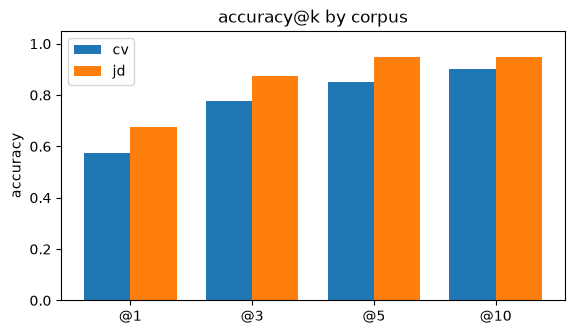

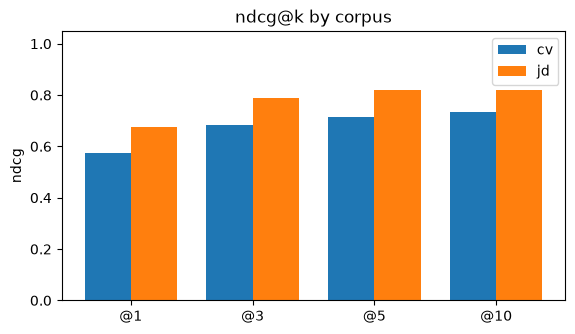

In [7]:
# One chart per figure, default matplotlib colors.
per_kind = {"cv": summary_cv.iloc[0], "jd": summary_jd.iloc[0]}

for metric in ("accuracy", "ndcg"):
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    width = 0.38
    xs = range(len(K_VALUES))
    for offset, (kind, row) in zip((-width / 2, width / 2), per_kind.items()):
        values = [row[f"{metric}@{k}"] for k in K_VALUES]
        ax.bar([x + offset for x in xs], values, width=width, label=kind)
    ax.set_xticks(list(xs))
    ax.set_xticklabels([f"@{k}" for k in K_VALUES])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@k by corpus")
    ax.legend()
    plt.show()

### Reading the layer-1 metrics

- **rank** — 1-based position of the true document in the ranked list (`None` if it never
  surfaced within `SEARCH_K`). Everything below derives from it because each query has exactly
  one relevant document.
- **MRR** (mean reciprocal rank) — average of `1/rank`; 1.0 means the true document is always
  first, 0.5 means it is on average second.
- **accuracy@k** (hit rate) — share of queries whose true document appears in the top *k*.
  `accuracy@1` is strict top-hit accuracy; `accuracy@10` shows whether the document is at least
  reachable within the search depth.
- **precision@k** — fraction of the top *k* slots holding a relevant document. With a single
  relevant document it is bounded by `1/k`, so it mostly mirrors accuracy here.
- **DCG@k / IDCG@k / NDCG@k** — `DCG@k = Σ gain_i / log2(i+1)`; IDCG is the DCG of the ideal
  (descending-gain) ordering, and NDCG = DCG / IDCG. With one relevant document of gain 1.0,
  IDCG@k = 1 for every k ≥ 1, so `NDCG@k = 1/log2(rank+1)` when the document is ranked ≤ k, else
  0 — a smooth, position-sensitive version of accuracy@k.

## 1b · Optional: LLM-graded NDCG

The binary labels above undercount quality: a query like *"senior Java developer with Spring"*
may retrieve several genuinely relevant resumes besides the one it was generated from. In this
pass the judge model grades each of the top-5 retrieved documents on a 0–2 scale, and NDCG is
recomputed with those graded gains.

**Why IDCG becomes non-trivial here:** with a single binary label the ideal ranking always has
DCG = 1, so NDCG collapses to a discount on the rank of one document. With graded gains the
ideal ranking is the judged grades sorted descending — e.g. grades `[1, 2, 0, 2, 1]` have
IDCG@5 = `2/log2(2) + 2/log2(3) + 1/log2(4) + 1/log2(5) ≈ 4.19` — so NDCG now measures how close
the actual ordering is to the best possible ordering *of everything the search returned*, not
just where one document landed. (Caveat: only the retrieved top-k is judged, so IDCG is ideal
relative to the retrieved pool, not the whole corpus.)

In [8]:
# Judge the top-5 for a small mixed sample of queries (GRADED_N x 5 judge calls).
graded_ds = retrieval_cv[: GRADED_N // 2] + retrieval_jd[: GRADED_N - GRADED_N // 2]
graded = run_graded_ndcg(graded_ds, k=5)

graded_cols = [c for c in graded.columns if c.startswith(("dcg@", "idcg@", "ndcg@"))]
display(graded[["query", "grades", *graded_cols]].round(4))
graded[graded_cols].mean().to_frame("mean").T.round(4)

,query,grades,dcg@5,idcg@5,ndcg@5
0,"Oracle DBA with over 6 years experience managing Oracle 10g to 12c, SQL Serv...","[1.0, 1.0, 0.0, 1.0, 0.0]",2.0616,2.1309,0.9675
1,"Director of Information Technology with expertise in C#, Oracle SQL, SQL Ser...","[1.0, 1.0, 0.0, 1.0, 1.0]",2.4485,2.5616,0.9558
2,"IT Manager with expertise in Active Directory, Microsoft Exchange 2003, Wind...","[1.0, 1.0, 1.0, 1.0, 1.0]",2.9485,2.9485,1.0000
3,Microsoft Certified Systems Engineer with experience as Information Technolo...,"[1.0, 1.0, 1.0, 1.0, 1.0]",2.9485,2.9485,1.0000
4,"Senior Data Scientist role in InsurTech with 8+ years experience, expertise ...","[2.0, 1.0, 1.0, 1.0, 2.0]",4.3353,4.5794,0.9467
5,Information Technology Consultant contract role with 5+ years in Java Seleni...,"[2.0, 1.0, 2.0, 1.0, 1.0]",4.4485,4.5794,0.9714
6,"Azure Data Engineer contract role in banking with 8+ years experience, exper...","[2.0, 1.0, 1.0, 1.0, 1.0]",3.9485,3.9485,1.0000
7,Quantitative Researcher position requiring expertise in statistical analysis...,"[2.0, 2.0, 2.0, 2.0, 2.0]",5.8969,5.8969,1.0000


,dcg@5,idcg@5,ndcg@5
mean,3.6295,3.6992,0.9802


## 2 · Layer 2 — Generation & hallucination (RAGAS)

For each sampled document the judge model writes one factual question answerable from that
document alone, plus a concise ground-truth answer. The pipeline then mirrors production
end-to-end: embed the question, retrieve `CONTEXT_K` grouped contexts shaped exactly like the
production tool layer, and answer with `gpt-4.1` under the **exact production system prompt**
(`services/ai-agents/prompt/system.md`). RAGAS (judged by `gpt-4.1-mini`) then scores each
(question, contexts, answer, ground_truth) sample.

In [9]:
qa_cv = build_qa_dataset("cv", n=QA_N, seed=SEED, force=FORCE_REBUILD)
qa_jd = build_qa_dataset("jd", n=QA_N, seed=SEED, force=FORCE_REBUILD)

for kind, ds in (("cv", qa_cv), ("jd", qa_jd)):
    print(f"--- sample {kind} QA pairs ---")
    for item in ds[:2]:
        print(f"  Q: {item['question']}")
        print(f"  ground truth: {item['ground_truth']}\n")

--- sample cv QA pairs ---
  Q: What database management systems and cloud platforms does the candidate have hands-on experience with?
  ground truth: The candidate has hands-on experience with Oracle databases (10g, 11g, 12c), MySQL (5.6, 5.7), SQL Server (2008, 2012), and AWS infrastructure including RDS, EC2, S3, and related services.

  Q: What leadership roles has the candidate held in their IT career?
  ground truth: The candidate has held leadership roles including Director of Information Technology, Team Leader, Chief Information Officer, and Director of Applications Development.

--- sample jd QA pairs ---
  Q: What programming languages and tools are required for the Senior Data Scientist (InsurTech) role?
  ground truth: The role requires strong programming skills in Python, PySpark, SQL, and reproducible data workflows.

  Q: What are the mandatory technical skills required for the Information Technology Consultant (Test Automation) contract role?
  ground truth: The mandat

In [10]:
# Retrieve + answer for every QA item (cached under eval_data/gen_*.json).
gen_cv = run_generation(qa_cv, k=CONTEXT_K, force=FORCE_REBUILD)
gen_jd = run_generation(qa_jd, k=CONTEXT_K, force=FORCE_REBUILD)
samples = gen_cv + gen_jd
print(f"{len(samples)} generated samples ({len(gen_cv)} cv + {len(gen_jd)} jd)\n")

example = samples[0]
print("Q:", example["question"])
print("\nfirst context:", example["contexts"][0][:300], "…")
print("\nanswer:", example["answer"][:500])

30 generated samples (15 cv + 15 jd)

Q: What database management systems and cloud platforms does the candidate have hands-on experience with?

first context: resume #32959732 [technical_skills]: Enterprise Resource Planning Systems; Campus Nexus Student; Student and Faculty portal; Sage Platinum; Microsoft Great Plains; AccountMate; SAP Business One; Dialoge EDU; eCollege; Moodle Rooms; BatchMaster; Microsoft Great Plains CRM; Campus Nexus CRM; Enterpris …

answer: Based on the retrieved results, the candidate in resume #29051656 has hands-on experience with the following:

**Database Management Systems:**
- Oracle (10g, 11g, 12c)
- MySQL (5.6, 5.7)
- SQL Server (2008, 2012)

**Cloud Platforms:**
- AWS (Amazon Web Services), including:
  - RDS
  - EC2
  - S3
  - EBS Volumes
  - Security Groups
  - Snapshots

This candidate explicitly mentions over 6 years of experience supporting Oracle databases, SQL Server databases, and AWS infrastructure, handling task


In [11]:
# RAGAS scoring: faithfulness, answer_correctness, answer relevancy,
# context precision (with reference) and context recall.
ragas_df = run_ragas(samples)

score_cols = [
    c
    for c in ragas_df.columns
    if c not in ("user_input", "retrieved_contexts", "response", "reference",
                 "question", "answer", "ground_truth")
    and pd.api.types.is_numeric_dtype(ragas_df[c])
]
print("score columns:", score_cols)
ragas_df[["question", *score_cols]].round(3)

/Users/anh/Doc/resume-scan-project/pre-processing/.venv-eval/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


score columns: ['faithfulness', 'answer_correctness', 'answer_relevancy', 'llm_context_precision_with_reference', 'context_recall']


,question,faithfulness,answer_correctness,answer_relevancy,llm_context_precision_with_reference,context_recall
0,What database management systems and cloud platforms does the candidate have...,1.000,0.626,0.552,0.367,1.000
1,What leadership roles has the candidate held in their IT career?,0.955,0.243,0.956,0.000,0.000
2,What certifications does the candidate hold related to video surveillance?,1.000,0.962,0.918,1.000,1.000
3,What certifications does the candidate hold related to information technolog...,1.000,0.119,0.975,0.000,0.500
4,What certifications does the candidate hold related to Oracle and informatio...,0.833,0.448,0.872,1.000,1.000
5,What laboratory techniques and instruments is the candidate experienced with...,0.974,0.453,0.938,1.000,0.000
6,What certifications does the candidate hold related to network engineering a...,0.952,0.320,0.972,0.000,0.000
7,What technical skills does the candidate have related to network administrat...,1.000,0.518,0.905,1.000,1.000
8,What programming languages and frameworks does the candidate have experience...,0.917,0.225,0.762,0.200,1.000
9,What certifications does the candidate hold related to IT and networking?,1.000,0.642,0.924,0.450,1.000


In [12]:
report = hallucination_report(ragas_df, threshold=HALLUCINATION_THRESHOLD)
print(f"samples:                  {report['n']}")
print(f"hallucination rate:       {report['hallucination_rate']:.1%}"
      f"  (faithfulness < {HALLUCINATION_THRESHOLD})")
print(f"mean faithfulness:        {report['mean_faithfulness']:.3f}")
print(f"mean answer_correctness:  {report['mean_answer_correctness']:.3f}")
report["flagged"]  # least faithful answers first

samples:                  30
hallucination rate:       0.0%  (faithfulness < 0.7)
mean faithfulness:        0.967
mean answer_correctness:  0.439


,question,answer,faithfulness


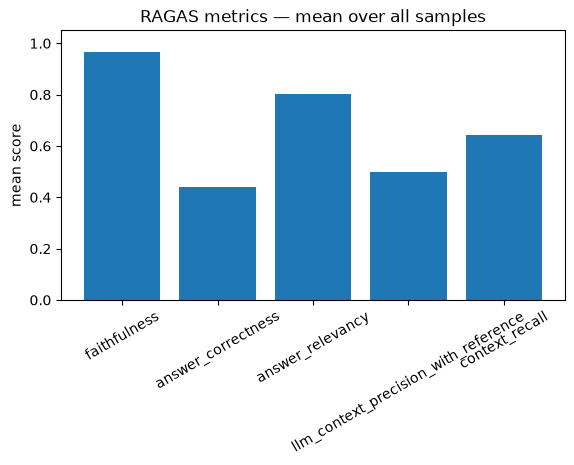

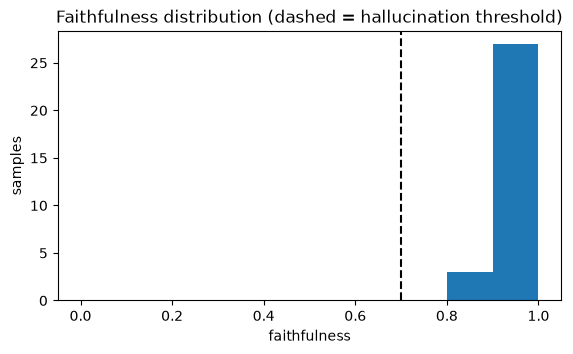

In [13]:
# One chart per figure, default colors.
means = ragas_df[score_cols].mean()

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(means.index, means.values)
ax.set_ylim(0, 1.05)
ax.set_ylabel("mean score")
ax.set_title("RAGAS metrics — mean over all samples")
ax.tick_params(axis="x", rotation=30)
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(pd.to_numeric(ragas_df["faithfulness"], errors="coerce").dropna(),
        bins=10, range=(0, 1))
ax.axvline(HALLUCINATION_THRESHOLD, linestyle="--", color="black")
ax.set_xlabel("faithfulness")
ax.set_ylabel("samples")
ax.set_title("Faithfulness distribution (dashed = hallucination threshold)")
plt.show()

### Hallucination vs. correctness — what layer 2 measures

- **Hallucination = `faithfulness < HALLUCINATION_THRESHOLD`.** Faithfulness decomposes the
  answer into claims and checks each one against the *retrieved contexts*. A low score means the
  model asserted things its context does not support — the classic RAG failure mode — regardless
  of whether those things happen to be true. A `NaN` faithfulness also counts as flagged (the
  claim check could not be completed, so the answer is unverified).
- **`answer_correctness`** compares the answer with the *ground truth* instead. The two
  disagree in informative ways: faithful-but-incorrect usually means **retrieval** brought back
  the wrong document (the model honestly summarised the wrong context); unfaithful-but-correct
  means the model answered from parametric memory rather than the contexts.
- `answer_relevancy` catches evasive or off-topic answers; `context precision/recall` attribute
  low scores to the retrieval step (was the needed evidence retrieved, and ranked high?).

## 3 · Persist results

Per-query (layer 1) and per-sample (layer 2) tables plus the summary/report go to
`eval_data/results/`, stamped with the run timestamp.

In [14]:
run_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
out = config.RESULTS_DIR

paths = {
    "retrieval_cv_perquery": out / f"retrieval_cv_perquery_{run_ts}.csv",
    "retrieval_jd_perquery": out / f"retrieval_jd_perquery_{run_ts}.csv",
    "retrieval_summary": out / f"retrieval_summary_{run_ts}.csv",
    "ragas_persample": out / f"ragas_persample_{run_ts}.csv",
    "report_json": out / f"hallucination_report_{run_ts}.json",
}
df_cv.to_csv(paths["retrieval_cv_perquery"], index=False)
df_jd.to_csv(paths["retrieval_jd_perquery"], index=False)
summary.to_csv(paths["retrieval_summary"], index=False)
ragas_df.to_csv(paths["ragas_persample"], index=False)

report_json = {
    "run": run_ts,
    "parameters": {
        "retrieval_n": RETRIEVAL_N,
        "qa_n": QA_N,
        "seed": SEED,
        "k_values": list(K_VALUES),
        "search_k": SEARCH_K,
        "context_k": CONTEXT_K,
        "hallucination_threshold": HALLUCINATION_THRESHOLD,
        "graded_n": GRADED_N,
    },
    "retrieval_summary": summary.to_dict(orient="records"),
    "graded_ndcg_mean": graded[graded_cols].mean().to_dict(),
    "generation": {
        "n": report["n"],
        "hallucination_rate": report["hallucination_rate"],
        "mean_faithfulness": report["mean_faithfulness"],
        "mean_answer_correctness": report["mean_answer_correctness"],
        "ragas_means": means.to_dict(),
        "flagged": report["flagged"].to_dict(orient="records"),
    },
}
paths["report_json"].write_text(
    json.dumps(report_json, indent=2, ensure_ascii=False, default=float)
)

for name, path in paths.items():
    print(f"{name:22s} -> {path}")

retrieval_cv_perquery  -> /Users/anh/Doc/resume-scan-project/pre-processing/eval_data/results/retrieval_cv_perquery_20260828_232818.csv
retrieval_jd_perquery  -> /Users/anh/Doc/resume-scan-project/pre-processing/eval_data/results/retrieval_jd_perquery_20260828_232818.csv
retrieval_summary      -> /Users/anh/Doc/resume-scan-project/pre-processing/eval_data/results/retrieval_summary_20260828_232818.csv
ragas_persample        -> /Users/anh/Doc/resume-scan-project/pre-processing/eval_data/results/ragas_persample_20260828_232818.csv
report_json            -> /Users/anh/Doc/resume-scan-project/pre-processing/eval_data/results/hallucination_report_20260828_232818.json


## Results summary

Fill this table from the summary/report cells above after a full run (the same numbers are in
`eval_data/results/`):

| Metric | cv | jd | combined |
|---|---|---|---|
| accuracy@1 | — | — | — |
| accuracy@3 | — | — | — |
| accuracy@5 | — | — | — |
| accuracy@10 | — | — | — |
| MRR | — | — | — |
| NDCG@5 | — | — | — |
| NDCG@10 | — | — | — |

| Generation (RAGAS) | value |
|---|---|
| hallucination rate (faithfulness < 0.7) | — |
| mean faithfulness | — |
| mean answer_correctness | — |
| mean answer_relevancy | — |
| mean context precision / recall | — / — |

**How to read this**

- `accuracy@1` near 1.0 → the true document is almost always the top hit; a large gap between
  `accuracy@1` and `accuracy@10` means the right document is *found* but *under-ranked* — a
  reranking problem, not a recall problem.
- MRR and NDCG add position sensitivity: NDCG@k ≈ accuracy@k only when hits are at rank 1;
  lower NDCG with equal accuracy means hits sit deeper in the list.
- The LLM-graded NDCG (1b) is the fairer number when several documents can satisfy a query;
  binary NDCG is the stricter, cheaper proxy.
- Hallucination rate is the headline generation number: the share of answers making claims the
  retrieved contexts do not support. Cross-check flagged rows — low faithfulness with low
  context precision/recall points at retrieval, low faithfulness with good contexts points at
  the generator/prompt.
- All ground truth here is synthetic (single-document, judge-written) and RAGAS scores carry
  LLM-judge variance — treat small deltas (< ~0.05) between runs as noise, and prefer comparing
  configurations on the *same* cached datasets (same `n`/`seed`).